# 🔋 Energy Consumption Prediction
This project predicts energy consumption using machine learning models.

# 📦 Import Libraries
We import required libraries for data analysis and machine learning.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
%pip install notebook ipykernel pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📊 Data Loading
Load dataset and view initial rows.

In [5]:
df = pd.read_csv("data/train_energy_data.csv")
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


# 🔍 Data Overview
Understand structure, data types, and summary statistics.

In [20]:
df.info() 
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


# 📈 Exploratory Data Analysis (EDA)
Analyze patterns and relationships in the dataset.

In [6]:
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]

# ⚙️ Data Preprocessing
Prepare data using scaling and encoding.

In [7]:
numerical_features = ["Square Footage", "Number of Occupants", "Appliances Used", "Average Temperature"]
categorical_features = ["Building Type", "Day of Week"]

In [8]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 🔀 Data Splitting
Split data into training and testing sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🤖 Model Building
Train multiple regression models.

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

# 📊 Model Evaluation
Evaluate models using MAE, MSE, RMSE, and R².

In [11]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, mse, rmse, r2])

In [12]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2"])
print(results_df)

               Model         MAE            MSE        RMSE        R2
0  Linear Regression    0.011412       0.000189    0.013731  1.000000
1              Ridge    1.498854       3.317414    1.821377  0.999996
2              Lasso    2.995206      13.164138    3.628242  0.999984
3         ElasticNet  290.660252  130578.995386  361.357158  0.839643


### Distribution of Energy Consumption
Check if data is normally distributed.

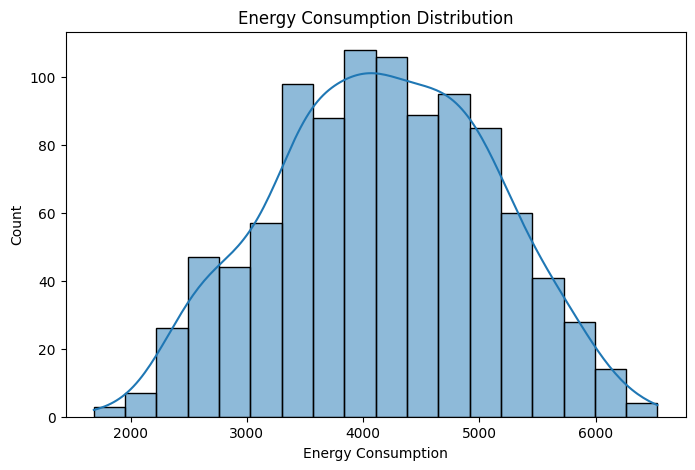

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Energy Consumption"], kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

### Energy Consumption by Building Type
Analyze how building type affects consumption.

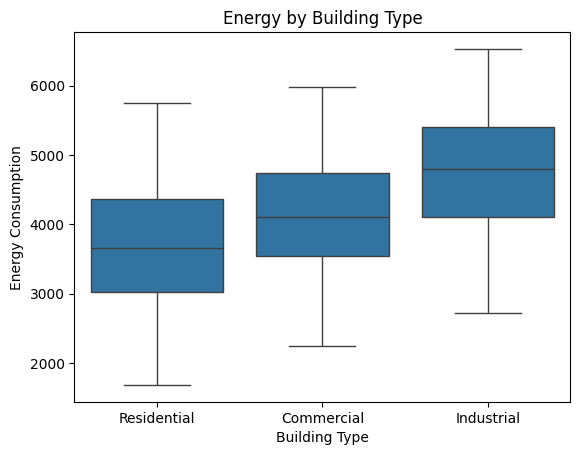

In [16]:
sns.boxplot(x="Building Type", y="Energy Consumption", data=df)
plt.title("Energy by Building Type")
plt.show()

### Correlation Analysis
Understand relationships between numerical features.

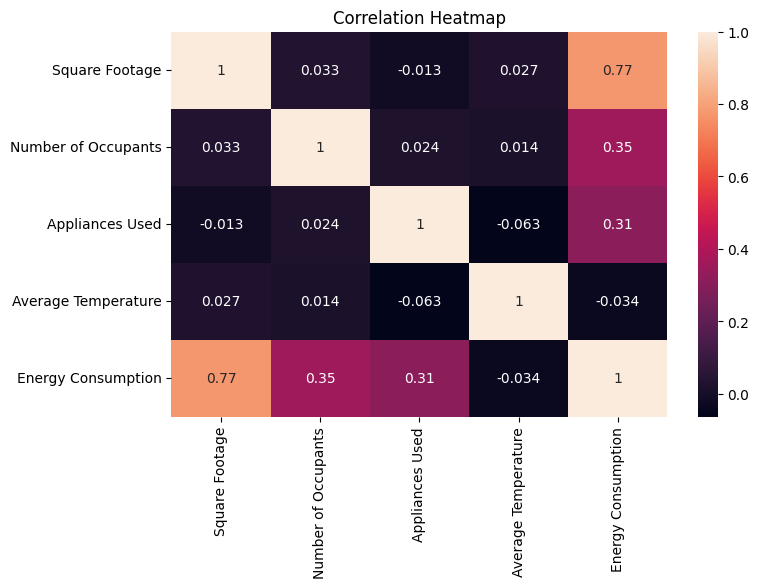

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
results_df.sort_values(by="R2", ascending=False)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.011412,0.000189,0.013731,1.000000
1,Ridge,1.498854,3.317414,1.821377,0.999996
2,Lasso,2.995206,13.164138,3.628242,0.999984
3,ElasticNet,290.660252,130578.995386,361.357158,0.839643


Best Model: Linear Regression  
Reason: Highest R² score and better interpretability  

# 📉 Actual vs Predicted Analysis
Compare predicted values with actual values.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


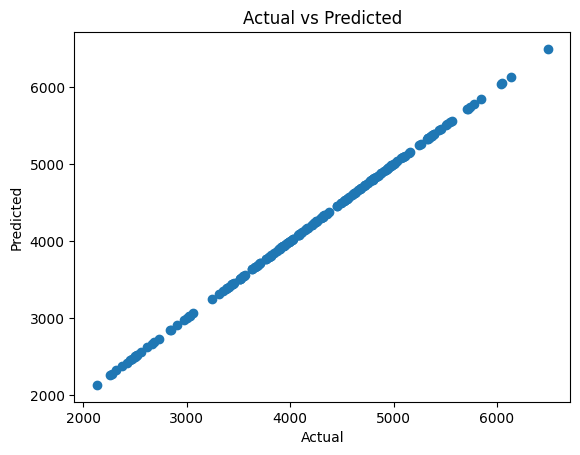

In [13]:
import matplotlib.pyplot as plt

best_model = LinearRegression()

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [19]:
import joblib

joblib.dump(pipeline, "model.pkl")

['model.pkl']

# ✅ Conclusion

Linear Regression performed best with highest accuracy and interpretability.

Key Insights:
- Square Footage has highest impact
- Building Type strongly affects consumption
- Model achieved very high accuracy